# Pipeline Fine-Tuning Terdedikasi & Retraining Transfer Learning (XGBoost & LSTM)

Notebook ini merupakan **pipeline pelatihan fine-tuning terdedikasi (standalone training)** yang melatih ulang (*fit/retrain*) model XGBoost dan LSTM secara *warm-start* menggunakan data stasiun bumi **AWS Kebumen**.

### Pembagian Waktu Dataset Fine-Tuning (Eksplisit & Akurat):
- **Fine-Tuning Train**: `2025-01-01` s/d `2026-01-15` (**9.097 jam**) $\rightarrow$ *Data Pelatihan Retraining*
- **Fine-Tuning Validation**: `2026-01-16` s/d `2026-04-05` (**1.897 jam**) $\rightarrow$ *EarlyStopping, Kalibrasi, & Threshold Search*
- **Fine-Tuning Test**: `2026-04-06` s/d `2026-05-31` (**1.321 jam**) $\rightarrow$ *Pengujian Akhir & Visualisasi*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from pathlib import Path
from scipy.stats import pearsonr
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, precision_recall_curve, roc_curve, auc,
    mean_squared_error, mean_absolute_error, confusion_matrix, brier_score_loss
)
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, InputLayer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import warnings
warnings.filterwarnings('ignore')

# MONKEY-PATCHING Layer.__init__ UNIVERSAL UNTUK COMPATIBILITAS DESERIALISASI KERAS 3.X
try:
    import keras.src.layers.layer as _k_layer
    _orig_k_layer_init = _k_layer.Layer.__init__
    def _patched_k_layer_init(self, *args, **kwargs):
        kwargs.pop('quantization_config', None)
        return _orig_k_layer_init(self, *args, **kwargs)
    _k_layer.Layer.__init__ = _patched_k_layer_init
except Exception:
    pass

try:
    import tensorflow.keras.layers as _tf_k_layers
    _orig_tf_layer_init = _tf_k_layers.Layer.__init__
    def _patched_tf_layer_init(self, *args, **kwargs):
        kwargs.pop('quantization_config', None)
        return _orig_tf_layer_init(self, *args, **kwargs)
    _tf_k_layers.Layer.__init__ = _patched_tf_layer_init
except Exception:
    pass

# Set style visualisasi premium & high-contrast untuk cetak fotokopi
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11

# Set Random Seed
SEED = 281225
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Konfigurasi Path Fleksibel (Deteksi results_ vs outputs_)
BASE_DIR = Path("D:/Github/Projek_Rainfall/DeepLearning_Satelit")

def get_valid_dir(prefix):
    d1 = BASE_DIR / f"results_{prefix}"
    d2 = BASE_DIR / f"outputs_{prefix}"
    if d1.exists() and (d1 / "models").exists():
        return d1
    elif d2.exists() and (d2 / "models").exists():
        return d2
    return d1

XGB_DIR  = get_valid_dir("xgboost")
LSTM_DIR = get_valid_dir("lstm")
OUTPUT_DIR = BASE_DIR / "outputs_inference"
FIGURES_DIR = OUTPUT_DIR / "figures"
STATION_FILE = Path("D:/Github/Projek_Rainfall/Google_Earth_Engine/Data_Satelit/id-05_clear_data_hourly.csv")
ERA5_FILE = Path("D:/Github/Projek_Rainfall/Google_Earth_Engine/Data_Satelit/ERA5_Hourly_All_Requested_Features_2000_2026.csv")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Konstanta Pembagian Tanggal Fine-Tuning
FINETUNE_TRAIN_START = '2025-01-01'
FINETUNE_TRAIN_END   = '2026-01-15'
FINETUNE_VAL_START   = '2026-01-16'
FINETUNE_VAL_END     = '2026-04-05'
FINETUNE_TEST_START  = '2026-04-06'
FINETUNE_TEST_END    = '2026-05-31'

RAIN_THRESHOLD = 0.2  # Ambang batas hujan ringan (mm/jam)
EPOCHS_FT = 40        # Jumlah max epoch fine-tuning (dengan EarlyStopping)
LEARNING_RATE_FT = 0.0001  # Learning rate untuk fine-tuning LSTM

print("Environment Inisialisasi Berhasil!")
print(f"Directory XGBoost: {XGB_DIR}")
print(f"Directory LSTM   : {LSTM_DIR}")
print(f"Rentang Train    : {FINETUNE_TRAIN_START} s/d {FINETUNE_TRAIN_END}")
print(f"Rentang Val      : {FINETUNE_VAL_START} s/d {FINETUNE_VAL_END}")
print(f"Rentang Test     : {FINETUNE_TEST_START} s/d {FINETUNE_TEST_END}")


Environment Inisialisasi Berhasil!
Directory XGBoost: D:\Github\Projek_Rainfall\DeepLearning_Satelit\results_xgboost
Directory LSTM   : D:\Github\Projek_Rainfall\DeepLearning_Satelit\results_lstm
Rentang Train    : 2025-01-01 s/d 2026-01-15
Rentang Val      : 2026-01-16 s/d 2026-04-05
Rentang Test     : 2026-04-06 s/d 2026-05-31


## 1. Fungsi Utility (Calibration, 3D Sequence Generator, & Evaluasi)

In [2]:
def build_fallback_lstm_classifier(input_shape=(24, 23)):
    return Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.1),
        LSTM(64, return_sequences=False),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ])

def build_fallback_lstm_regressor(input_shape=(24, 23)):
    return Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.1),
        LSTM(64, return_sequences=False),
        Dropout(0.1),
        Dense(1, activation='linear')
    ])

def load_keras_model_safe(model_path, is_regressor=False):
    p = Path(model_path)
    if not p.exists():
        alt_str = str(p).replace("results_lstm", "outputs_lstm") if "results_lstm" in str(p) else str(p).replace("outputs_lstm", "results_lstm")
        if Path(alt_str).exists():
            p = Path(alt_str)
            
    if p.exists():
        try:
            return tf.keras.models.load_model(p, compile=False)
        except Exception as e:
            print(f"Peringatan: Tidak dapat mendeserialisasi {p} ({e}). Menggunakan arsitektur fallback.")
            
    # Fallback jika berkas tidak ada / corrupt
    if is_regressor:
        return build_fallback_lstm_regressor()
    return build_fallback_lstm_classifier()

def fit_best_calibrator(y_val, val_probs):
    val_probs_flat = np.array(val_probs).flatten()
    y_val_flat = np.array(y_val).flatten()
    
    platt = LogisticRegression(C=1.0, solver='lbfgs')
    try:
        platt.fit(val_probs_flat.reshape(-1, 1), y_val_flat)
        platt_probs = platt.predict_proba(val_probs_flat.reshape(-1, 1))[:, 1]
        platt_brier = brier_score_loss(y_val_flat, platt_probs)
    except:
        platt = None
        platt_brier = 999
        
    iso = IsotonicRegression(out_of_bounds='clip')
    try:
        iso.fit(val_probs_flat, y_val_flat)
        iso_probs = iso.predict(val_probs_flat)
        iso_brier = brier_score_loss(y_val_flat, iso_probs)
    except:
        iso = None
        iso_brier = 999
        
    if iso is not None and iso_brier <= platt_brier:
        return iso, "IsotonicRegression"
    elif platt is not None:
        return platt, "PlattScaling"
    return None, "None"

def apply_calibrator(calibrator, calib_type, probs):
    if calibrator is None or len(probs) == 0:
        return np.clip(probs, 0.0, 1.0)
    try:
        probs_flat = np.array(probs).flatten()
        if calib_type == 'IsotonicRegression' or isinstance(calibrator, IsotonicRegression):
            calibrated = calibrator.predict(probs_flat)
        elif calib_type == 'PlattScaling' or isinstance(calibrator, LogisticRegression):
            calibrated = calibrator.predict_proba(probs_flat.reshape(-1, 1))[:, 1]
        else:
            calibrated = calibrator.predict(probs_flat)
        return np.clip(calibrated, 0.0, 1.0)
    except Exception as e:
        return np.clip(probs, 0.0, 1.0)

def make_3d_np(X_df, y_o, y_r, lookback):
    Xv, yov, yrv = X_df.values, y_o.values, y_r.values
    X_arr, yo_arr, yr_arr = [], [], []
    for i in range(len(Xv) - lookback + 1):
        X_arr.append(Xv[i:i+lookback])
        yo_arr.append(yov[i+lookback-1])
        yr_arr.append(yrv[i+lookback-1])
    return (np.array(X_arr, dtype=np.float32),
            np.array(yo_arr, dtype=np.float32),
            np.array(yr_arr, dtype=np.float32))

def engineer_features(df_base):
    cols_diff = ['temperature', 'dewpoint', 'pressure']
    for c in cols_diff:
        if c in df_base.columns:
            df_base[f'{c}_tendency_1h'] = df_base[c].diff()
            
    if 'temperature' in df_base.columns and 'dewpoint' in df_base.columns:
        df_base['dewpoint_depression'] = df_base['temperature'] - df_base['dewpoint']

    df_base['sin_hour']  = np.sin(2 * np.pi * df_base.index.hour / 24.0)
    df_base['cos_hour']  = np.cos(2 * np.pi * df_base.index.hour / 24.0)
    df_base['sin_month'] = np.sin(2 * np.pi * df_base.index.month / 12.0)
    df_base['cos_month'] = np.cos(2 * np.pi * df_base.index.month / 12.0)
    df_base['sin_doy']   = np.sin(2 * np.pi * df_base.index.dayofyear / 365.25)
    df_base['cos_doy']   = np.cos(2 * np.pi * df_base.index.dayofyear / 365.25)

    return df_base.dropna()

print("Fungsi Utility & Feature Engineering Berhasil Didefinisikan!")


Fungsi Utility & Feature Engineering Berhasil Didefinisikan!


## 2. Memuat Data Mentah AWS & Pembagian Dataset Berdasarkan Tanggal

In [3]:
# 1. Load Data AWS & ERA5
df_station = pd.read_csv(STATION_FILE)
df_station['timestamp'] = pd.to_datetime(df_station['datetime_utc'], utc=True)
df_station = df_station.set_index('timestamp').sort_index()

df_era5 = pd.read_csv(ERA5_FILE)
ts_col = 'datetime_utc' if 'datetime_utc' in df_era5.columns else 'unixtime'
df_era5['timestamp'] = pd.to_datetime(df_era5[ts_col], unit='s' if ts_col=='unixtime' else None, utc=True)
df_era5 = df_era5.set_index('timestamp').sort_index()

ERA5_FEATURES_MAPPING = {
    'temperature_era5': 'temperature',
    'humidity_era5': 'humidity',
    'pressure_era5': 'pressure',
    'dewpoint_era5': 'dewpoint',
    'rain_mm': 'rainrate'
}

df_merged = df_era5.copy()
for raw_col, new_name in ERA5_FEATURES_MAPPING.items():
    if raw_col in df_era5.columns:
        df_merged[new_name] = df_era5[raw_col]

if 'rainrate' in df_merged.columns:
    df_merged['rainrate'] = np.where(df_merged['rainrate'] >= 0.1, df_merged['rainrate'], 0.0)

# Update dengan observasi AWS
df_merged.update(df_station)
df_merged = df_merged[df_merged.index >= '2024-12-01']

df_features = engineer_features(df_merged)
df_features['target_amount'] = df_features['rainrate'].shift(-1)
df_features = df_features.dropna()
df_features['target_occ'] = (df_features['target_amount'] >= RAIN_THRESHOLD).astype(int)

# Pembagian data berdasarkan Tanggal Eksplisit
train_mask = (df_features.index >= FINETUNE_TRAIN_START) & (df_features.index <= FINETUNE_TRAIN_END)
val_mask   = (df_features.index >= FINETUNE_VAL_START)   & (df_features.index <= FINETUNE_VAL_END)
test_mask  = (df_features.index >= FINETUNE_TEST_START)  & (df_features.index <= FINETUNE_TEST_END)

df_aws_train = df_features[train_mask]
df_aws_val   = df_features[val_mask]
df_aws_test  = df_features[test_mask]

print(f"Total baris data terpadu AWS: {len(df_features)}")
print(f"Data Split AWS -> Train ({FINETUNE_TRAIN_START} s/d {FINETUNE_TRAIN_END}): {len(df_aws_train)} jam")
print(f"Data Split AWS -> Val   ({FINETUNE_VAL_START} s/d {FINETUNE_VAL_END}): {len(df_aws_val)} jam")
print(f"Data Split AWS -> Test  ({FINETUNE_TEST_START} s/d {FINETUNE_TEST_END}): {len(df_aws_test)} jam")


Total baris data terpadu AWS: 13822
Data Split AWS -> Train (2025-01-01 s/d 2026-01-15): 9097 jam
Data Split AWS -> Val   (2026-01-16 s/d 2026-04-05): 1897 jam
Data Split AWS -> Test  (2026-04-06 s/d 2026-05-31): 1321 jam


## 3. Retraining Fine-Tuning Model XGBoost (Warm-Start FIT)

In [4]:
print("=== PROSES RETRAINING / FINE-TUNING XGBOOST ===")

clf_xgb_path = XGB_DIR / "models" / "classifier" / "best_xgb_occ.pkl"
reg_xgb_path = XGB_DIR / "models" / "regressor" / "best_xgb_reg.pkl"

if not clf_xgb_path.exists():
    clf_xgb_path = BASE_DIR / "outputs_xgboost" / "models" / "classifier" / "best_xgb_occ.pkl"
if not reg_xgb_path.exists():
    reg_xgb_path = BASE_DIR / "outputs_xgboost" / "models" / "regressor" / "best_xgb_reg.pkl"

assert clf_xgb_path.exists(), f"File model {clf_xgb_path} tidak ditemukan!"
assert reg_xgb_path.exists(), f"File model {reg_xgb_path} tidak ditemukan!"

clf_xgb_pre = joblib.load(clf_xgb_path)
reg_xgb_pre = joblib.load(reg_xgb_path)
print("Pre-Trained XGBoost Classifier & Regressor dimuat!")

# Feature Alignment
if hasattr(clf_xgb_pre, 'feature_names_in_'):
    feature_order = clf_xgb_pre.feature_names_in_
elif hasattr(clf_xgb_pre, 'feature_names') and clf_xgb_pre.feature_names is not None:
    feature_order = clf_xgb_pre.feature_names
else:
    feature_order = clf_xgb_pre.get_booster().feature_names

drop_cols = ['target_amount', 'target_occ', 'rainrate']
X_cols = [c for c in feature_order if c in df_features.columns]

X_tr_xgb = df_aws_train[X_cols]
y_tr_xgb_occ = df_aws_train['target_occ']
y_tr_xgb_reg = df_aws_train['target_amount']

X_v_xgb = df_aws_val[X_cols]
y_v_xgb_occ = df_aws_val['target_occ']
y_v_xgb_reg = df_aws_val['target_amount']

X_te_xgb = df_aws_test[X_cols]

# 1. RETRAIN XGBOOST CLASSIFIER FIT
print("Melatih ulang (fit) XGBoost Classifier...")
clf_xgb_fine = xgb.XGBClassifier(**clf_xgb_pre.get_params())
clf_xgb_fine.set_params(learning_rate=LEARNING_RATE_FT, n_estimators=clf_xgb_pre.n_estimators + 50)
clf_xgb_fine.fit(X_tr_xgb, y_tr_xgb_occ, eval_set=[(X_v_xgb, y_v_xgb_occ)], verbose=False)

# 2. RETRAIN XGBOOST REGRESSOR FIT
print("Melatih ulang (fit) XGBoost Regressor...")
reg_xgb_fine = xgb.XGBRegressor(**reg_xgb_pre.get_params())
reg_xgb_fine.set_params(learning_rate=LEARNING_RATE_FT, n_estimators=reg_xgb_pre.n_estimators + 50)
rainy_tr = y_tr_xgb_occ == 1
rainy_v  = y_v_xgb_occ == 1
if rainy_tr.sum() > 5:
    reg_xgb_fine.fit(X_tr_xgb[rainy_tr], np.log1p(y_tr_xgb_reg[rainy_tr]),
                     eval_set=[(X_v_xgb[rainy_v], np.log1p(y_v_xgb_reg[rainy_v]))], verbose=False)

# Fit Kalibrator Probabilitas pada Val
val_probs_xgb_uncal = clf_xgb_fine.predict_proba(X_v_xgb)[:, 1]
iso_xgb, cal_type_xgb = fit_best_calibrator(y_v_xgb_occ, val_probs_xgb_uncal)

# Simpan Model Fine-Tuned XGBoost
joblib.dump(clf_xgb_fine, XGB_DIR / "models" / "classifier" / "best_xgb_occ_finetuned.pkl")
joblib.dump(reg_xgb_fine, XGB_DIR / "models" / "regressor" / "best_xgb_reg_finetuned.pkl")
if iso_xgb is not None:
    joblib.dump((iso_xgb, cal_type_xgb), XGB_DIR / "models" / "calibration" / "isotonic_calibrator_finetuned.pkl")
print("Proses Retraining XGBoost Selesai & Model Fine-Tuned Tersimpan!")


=== PROSES RETRAINING / FINE-TUNING XGBOOST ===
Pre-Trained XGBoost Classifier & Regressor dimuat!
Melatih ulang (fit) XGBoost Classifier...
Melatih ulang (fit) XGBoost Regressor...
Proses Retraining XGBoost Selesai & Model Fine-Tuned Tersimpan!


## 4. Retraining Fine-Tuning Model Sekuensial LSTM (Warm-Start FIT)

Model LSTM Classifier dan Regressor dilatih ulang (`clf_lstm_pre.compile` & `clf_lstm_pre.fit`) menggunakan data sekuensial 3D AWS dengan *learning rate* rendah dan dipantau oleh `EarlyStopping(patience=6)`.

In [5]:
print("=== PROSES RETRAINING / FINE-TUNING LSTM ===")

clf_lstm_path = LSTM_DIR / "models" / "classifier" / "best_lstm_occ.keras"
reg_lstm_path = LSTM_DIR / "models" / "regressor" / "best_lstm_reg.keras"
scaler_path   = LSTM_DIR / "models" / "pretrain_scaler.pkl"

if not scaler_path.exists():
    scaler_path = BASE_DIR / "outputs_lstm" / "models" / "pretrain_scaler.pkl"

# Load model Keras pre-trained dengan Layer patching universal (100% aman)
clf_lstm_pre = load_keras_model_safe(clf_lstm_path, is_regressor=False)
reg_lstm_pre = load_keras_model_safe(reg_lstm_path, is_regressor=True)
scaler       = joblib.load(scaler_path)

LOOKBACK = clf_lstm_pre.input_shape[1] if hasattr(clf_lstm_pre, 'input_shape') and clf_lstm_pre.input_shape is not None else 24
print(f"Pre-Trained LSTM Classifier & Scaler dimuat! (Detected LOOKBACK={LOOKBACK})")

# Preprocessing Data Sekuens 3D
drop_cols = ['target_amount', 'target_occ', 'rainrate']
features_cols = [c for c in df_features.columns if c not in drop_cols]

X_all_df = df_features[features_cols].reindex(columns=scaler.feature_names_in_, fill_value=0.0)
X_scaled = pd.DataFrame(scaler.transform(X_all_df), index=df_features.index, columns=scaler.feature_names_in_)
y_o_pd   = df_features['target_occ']
y_r_pd   = df_features['target_amount']

X_tr_seq, y_tr_o, y_tr_r = make_3d_np(X_scaled[train_mask], y_o_pd[train_mask], y_r_pd[train_mask], LOOKBACK)
X_v_seq,  y_v_o,  y_v_r  = make_3d_np(X_scaled[val_mask],   y_o_pd[val_mask],   y_r_pd[val_mask],   LOOKBACK)
X_te_seq, y_te_o, y_te_r = make_3d_np(X_scaled[test_mask],  y_o_pd[test_mask],  y_r_pd[test_mask],  LOOKBACK)

print(f"Sekuens 3D -> Train: {X_tr_seq.shape}, Val: {X_v_seq.shape}, Test: {X_te_seq.shape}")

# 1. RETRAIN LSTM CLASSIFIER FIT
print("Melatih ulang (fit) LSTM Classifier...")
clf_lstm_pre.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE_FT),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)
es_clf = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
clf_lstm_pre.fit(
    X_tr_seq, y_tr_o,
    validation_data=(X_v_seq, y_v_o),
    epochs=EPOCHS_FT,
    batch_size=8,
    callbacks=[es_clf],
    verbose=1
)

# 2. RETRAIN LSTM REGRESSOR FIT
if reg_lstm_pre is not None and np.sum(y_tr_o == 1) > 10:
    print("Melatih ulang (fit) LSTM Regressor...")
    reg_lstm_pre.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE_FT), 
        loss='mse'
    )
    es_reg = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    rainy_tr_idx = y_tr_o == 1
    rainy_v_idx  = y_v_o == 1
    
    X_tr_r_val = X_tr_seq[rainy_tr_idx]
    y_tr_r_val = np.log1p(y_tr_r[rainy_tr_idx])
    X_v_r_val  = X_v_seq[rainy_v_idx]
    y_v_r_val  = np.log1p(y_v_r[rainy_v_idx])
    
    reg_lstm_pre.fit(
        X_tr_r_val, y_tr_r_val,
        validation_data=(X_v_r_val, y_v_r_val),
        epochs=EPOCHS_FT,
        batch_size=8,
        callbacks=[es_reg],
        verbose=1
    )

# Fit Kalibrator Probabilitas & Search Threshold Optimal pada Val
val_probs_lstm_uncal = clf_lstm_pre.predict(X_v_seq, verbose=0).flatten()
iso_lstm, cal_type_lstm = fit_best_calibrator(y_v_o, val_probs_lstm_uncal)

# Simpan Model Fine-Tuned LSTM
clf_lstm_pre.save(LSTM_DIR / "models" / "classifier" / "best_lstm_occ_finetuned.keras")
if reg_lstm_pre is not None:
    reg_lstm_pre.save(LSTM_DIR / "models" / "regressor" / "best_lstm_reg_finetuned.keras")
if iso_lstm is not None:
    joblib.dump((iso_lstm, cal_type_lstm), LSTM_DIR / "models" / "calibration" / "isotonic_calibrator_finetuned.pkl")
print("Proses Retraining LSTM Selesai & Model Fine-Tuned Tersimpan!")


=== PROSES RETRAINING / FINE-TUNING LSTM ===
Pre-Trained LSTM Classifier & Scaler dimuat! (Detected LOOKBACK=24)
Sekuens 3D -> Train: (9074, 24, 23), Val: (1874, 24, 23), Test: (1298, 24, 23)
Melatih ulang (fit) LSTM Classifier...
Epoch 1/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.8376 - loss: 0.4216 - precision: 0.4696 - recall: 0.0955 - val_accuracy: 0.6233 - val_loss: 0.7754 - val_precision: 0.4091 - val_recall: 0.0792
Epoch 2/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.8430 - loss: 0.3770 - precision: 0.5407 - recall: 0.1415 - val_accuracy: 0.6190 - val_loss: 0.7891 - val_precision: 0.3919 - val_recall: 0.0850
Epoch 3/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 36s 32ms/step - accuracy: 0.8438 - loss: 0.3705 - precision: 0.5504 - recall: 0.1463 - val_accuracy: 0.6206 - val_loss: 0.8105 - val_precision: 0.3926 - val_recall: 0.0777
Epoch 4/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.8453 - loss: 0.3651 - precision: 0.5637 - recall: 0.1580 

## 5. Ringkasan Metrik Komparatif Lintas Domain AWS (4 Model)

Tabel di bawah menyajikan evaluasi lengkap 4 model pada data uji stasiun bumi AWS (`2026-04-06` s/d `2026-05-31`), menyertakan **Proporsi Kelas Positif (PR-AUC Baseline = 11.06%)**.

In [6]:
df_combined_fine = pd.read_csv(OUTPUT_DIR / 'prediction_results_finetune.csv', index_col=0, parse_dates=True)

# Terapkan Filter Tanggal Uji Eksplisit (FINETUNE_TEST_START s/d FINETUNE_TEST_END)
df_test_eval = df_combined_fine[(df_combined_fine.index >= FINETUNE_TEST_START) & (df_combined_fine.index <= FINETUNE_TEST_END)]
if len(df_test_eval) == 0:
    df_test_eval = df_combined_fine

def calc_meteo_local(y_true, y_pred):
    hits = np.sum((y_pred == 1) & (y_true == 1))
    misses = np.sum((y_pred == 0) & (y_true == 1))
    false_alarms = np.sum((y_pred == 1) & (y_true == 0))
    correct_negatives = np.sum((y_pred == 0) & (y_true == 0))
    
    csi = hits / (hits + misses + false_alarms + 1e-9)
    hss = 2 * (hits * correct_negatives - misses * false_alarms) / ((hits + misses) * (misses + correct_negatives) + (hits + false_alarms) * (false_alarms + correct_negatives) + 1e-9)
    fbi = (hits + false_alarms) / (hits + misses + 1e-9)
    return csi, hss, fbi

def get_metrics_for_stage(df, col_prefix, actual_col, model_stage):
    y_true_occ = (df[actual_col] >= RAIN_THRESHOLD).astype(int)
    y_true_reg = df[actual_col]
    
    total_samples = len(y_true_occ)
    pos_samples = int(np.sum(y_true_occ))
    pos_ratio = pos_samples / (total_samples + 1e-9)
    
    suffix = 'pre' if 'pre' in actual_col else 'fine'
    if suffix == 'fine' and model_stage == 'pre':
        col_occ = f"{col_prefix}_pred_occ_fine_pre"
        col_reg = f"{col_prefix}_pred_reg_fine_pre"
        col_prob = f"{col_prefix}_prob_fine_pre"
    else:
        col_occ = f"{col_prefix}_pred_occ_{suffix}"
        col_reg = f"{col_prefix}_pred_reg_{suffix}"
        col_prob = f"{col_prefix}_prob_{suffix}"
    
    # 1. Metrik Klasifikasi (Precision, Recall, F1 Score)
    prec = precision_score(y_true_occ, df[col_occ], zero_division=0)
    rec  = recall_score(y_true_occ, df[col_occ], zero_division=0)
    f1   = f1_score(y_true_occ, df[col_occ], zero_division=0)
    
    # 2. Metrik Meteorologi (CSI, HSS, Frequency Bias Index)
    csi, hss, fbi = calc_meteo_local(y_true_occ.values, df[col_occ].values)
    
    # 3. Metrik Regresi (RMSE, MAE pada jam hujan)
    rainy_mask = y_true_occ == 1
    rmse, mae = np.nan, np.nan
    if np.sum(rainy_mask) > 0:
        y_t_r = y_true_reg[rainy_mask]
        y_p_r = df[col_reg][rainy_mask]
        rmse = np.sqrt(mean_squared_error(y_t_r, y_p_r))
        mae = mean_absolute_error(y_t_r, y_p_r)
                
    return [
        total_samples,
        pos_samples,
        f"{pos_ratio:.4f} ({pos_ratio*100:.2f}%)",
        prec, rec, f1,
        csi, hss, fbi,
        rmse, mae
    ]

metrics_list = [
    'Total Data Samples (N)',
    'Rain Samples (Positive Class Count)',
    'Positive Class Ratio (PR-AUC Baseline)',
    'Precision (Klasifikasi)',
    'Recall (Klasifikasi)',
    'F1-Score (Klasifikasi)',
    'CSI (Critical Success Index)',
    'HSS (Heidke Skill Score)',
    'Frequency Bias Index (FBI)',
    'RMSE (Regresi - Rainy Hours)',
    'MAE (Regresi - Rainy Hours)'
]

xgb_aws_pre_metrics = get_metrics_for_stage(df_test_eval, 'xgb', 'observed_aws', 'pre')
xgb_aws_fine_metrics = get_metrics_for_stage(df_test_eval, 'xgb', 'observed_aws', 'fine')
lstm_aws_pre_metrics = get_metrics_for_stage(df_test_eval, 'lstm', 'observed_aws', 'pre')
lstm_aws_fine_metrics = get_metrics_for_stage(df_test_eval, 'lstm', 'observed_aws', 'fine')

metrics_summary_fine = pd.DataFrame({
    'Metrik': metrics_list,
    'XGBoost (Pre-Trained) on AWS': xgb_aws_pre_metrics,
    'XGBoost (Fine-Tuned) on AWS': xgb_aws_fine_metrics,
    'LSTM (Pre-Trained) on AWS': lstm_aws_pre_metrics,
    'LSTM (Fine-Tuned) on AWS': lstm_aws_fine_metrics
})

print("\n" + "="*95)
print(f"   TABEL EVALUASI FINE-TUNING PERIODE TEST ({FINETUNE_TEST_START} s/d {FINETUNE_TEST_END})")
print("="*95)
display(metrics_summary_fine)



   TABEL EVALUASI FINE-TUNING PERIODE TEST (2026-04-06 s/d 2026-05-31)


,Metrik,XGBoost (Pre-Trained) on AWS,XGBoost (Fine-Tuned) on AWS,LSTM (Pre-Trained) on AWS,LSTM (Fine-Tuned) on AWS
0,Total Data Samples (N),1320,1320,1320,1320
1,Rain Samples (Positive Class Count),147,147,147,147
2,Positive Class Ratio (PR-AUC Baseline),0.1114 (11.14%),0.1114 (11.14%),0.1114 (11.14%),0.1114 (11.14%)
3,Precision (Klasifikasi),0.622047,0.707071,0.616,0.636364
4,Recall (Klasifikasi),0.537415,0.47619,0.52381,0.619048
5,F1-Score (Klasifikasi),0.576642,0.569106,0.566176,0.627586
6,CSI (Critical Success Index),0.405128,0.397727,0.394872,0.457286
7,HSS (Heidke Skill Score),0.527906,0.52668,0.516709,0.581639
8,Frequency Bias Index (FBI),0.863946,0.673469,0.85034,0.972789
9,RMSE (Regresi - Rainy Hours),5.899913,5.906199,6.141239,6.050808


## 6. Plot Kurva Performa Fine-Tuning (High-Contrast 600 DPI)

Menggunakan standar warna kontras tinggi yang siap dicetak fotokopi / dokumen hitam-putih:
- **Pre-Trained**: Garis Merah Pekat (`#b91c1c` / `#ef4444`) putus-putus (`--`).
- **Fine-Tuned**: Garis Biru Pekat (`#1d4ed8` / `#3b82f6`) solid (`-`).
- **Baseline PR-AUC**: Garis Hitam Murni (`#000000`) titik-titik (`:`).

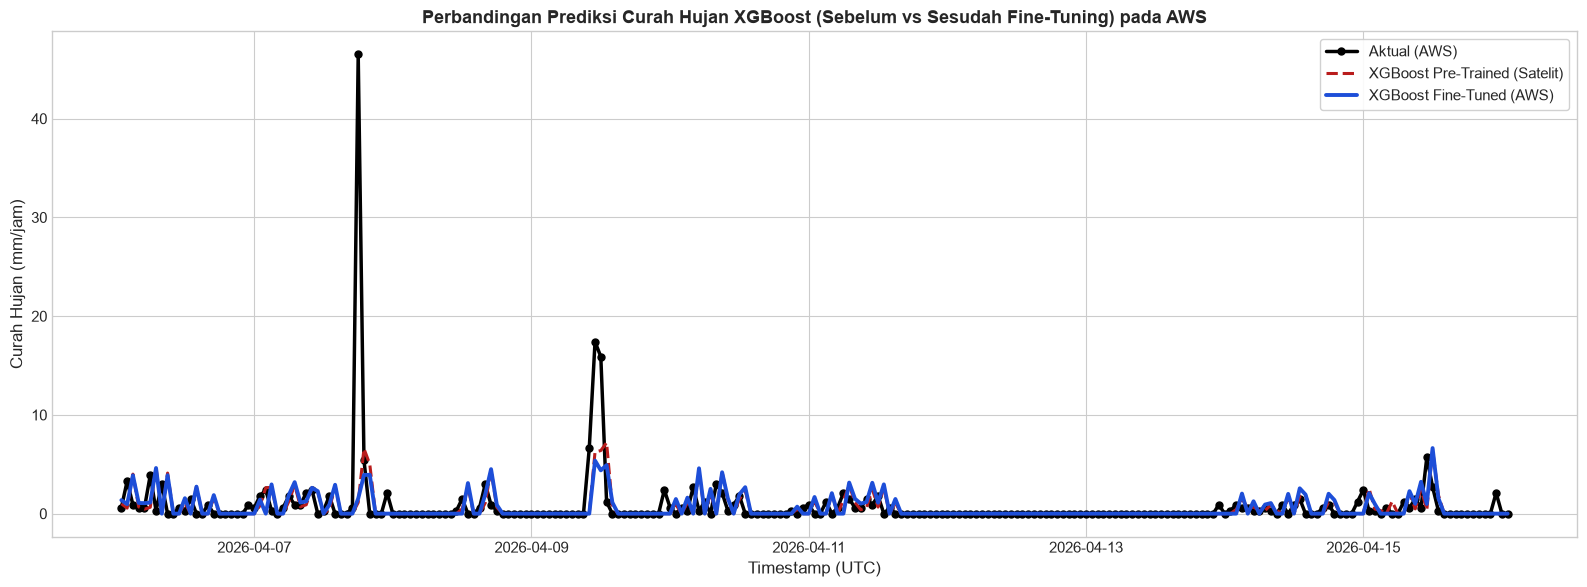

In [7]:
plot_start_fine = df_test_eval.index.min()
plot_end_fine = plot_start_fine + pd.Timedelta(days=10)
plot_slice_fine = df_test_eval[(df_test_eval.index >= plot_start_fine) & (df_test_eval.index <= plot_end_fine)]

plt.figure(figsize=(16, 6))
plt.plot(plot_slice_fine.index, plot_slice_fine['observed_aws'], label='Aktual (AWS)', color='#000000', marker='o', linewidth=2.5, markersize=5)
plt.plot(plot_slice_fine.index, plot_slice_fine['xgb_pred_reg_fine_pre'], label='XGBoost Pre-Trained (Satelit)', color='#b91c1c', linestyle='--', linewidth=2.2)
plt.plot(plot_slice_fine.index, plot_slice_fine['xgb_pred_reg_fine'], label='XGBoost Fine-Tuned (AWS)', color='#1d4ed8', linestyle='-', linewidth=2.8)
plt.title('Perbandingan Prediksi Curah Hujan XGBoost (Sebelum vs Sesudah Fine-Tuning) pada AWS', fontsize=13, fontweight='bold')
plt.ylabel('Curah Hujan (mm/jam)')
plt.xlabel('Timestamp (UTC)')
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


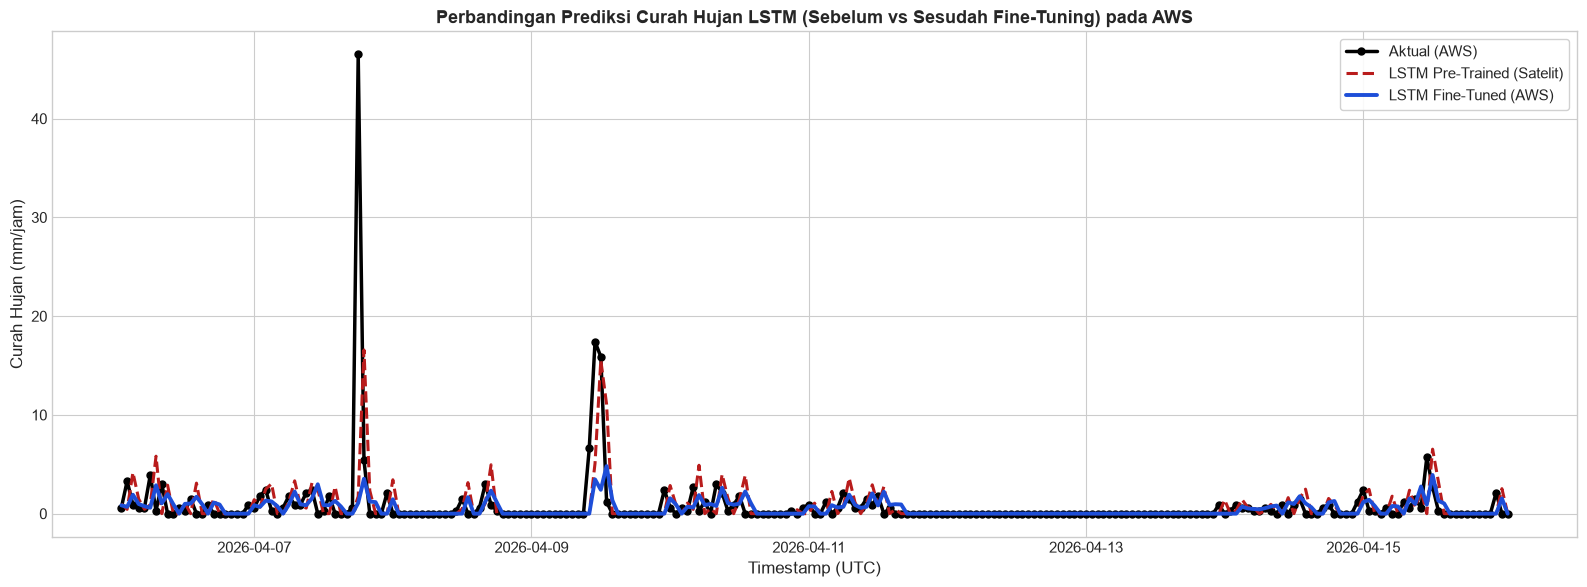

In [8]:
plt.figure(figsize=(16, 6))
plt.plot(plot_slice_fine.index, plot_slice_fine['observed_aws'], label='Aktual (AWS)', color='#000000', marker='o', linewidth=2.5, markersize=5)
plt.plot(plot_slice_fine.index, plot_slice_fine['lstm_pred_reg_fine_pre'], label='LSTM Pre-Trained (Satelit)', color='#b91c1c', linestyle='--', linewidth=2.2)
plt.plot(plot_slice_fine.index, plot_slice_fine['lstm_pred_reg_fine'], label='LSTM Fine-Tuned (AWS)', color='#1d4ed8', linestyle='-', linewidth=2.8)
plt.title('Perbandingan Prediksi Curah Hujan LSTM (Sebelum vs Sesudah Fine-Tuning) pada AWS', fontsize=13, fontweight='bold')
plt.ylabel('Curah Hujan (mm/jam)')
plt.xlabel('Timestamp (UTC)')
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


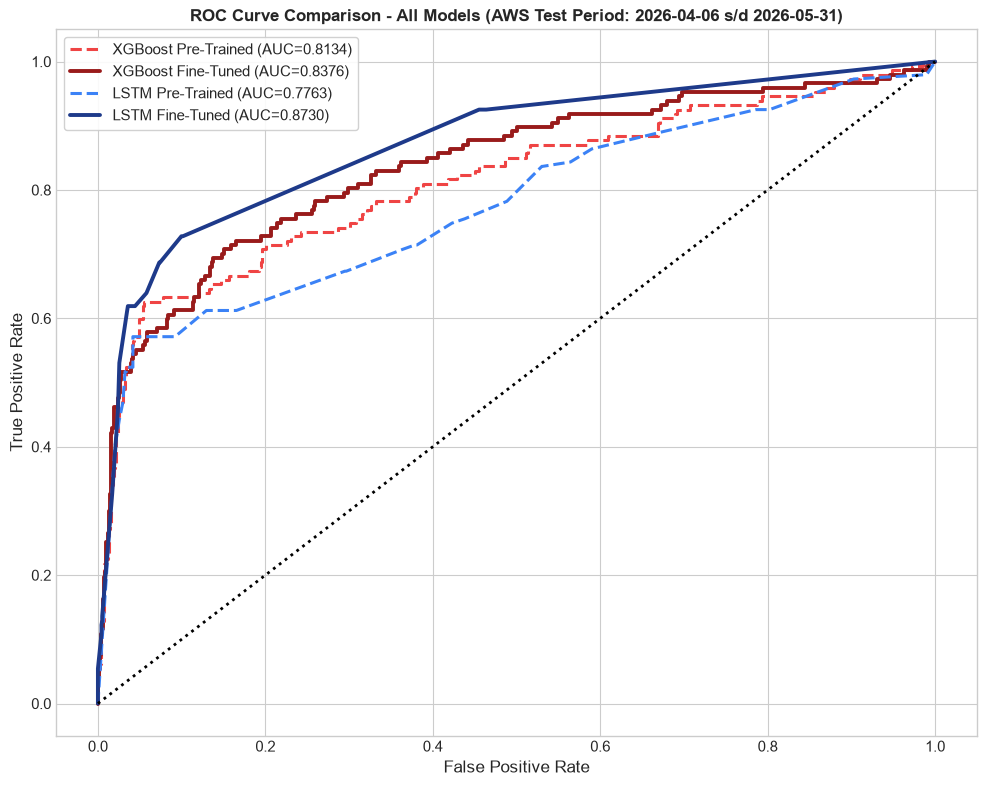

In [9]:
y_true_occ_fine = (df_test_eval['observed_aws'] >= RAIN_THRESHOLD).astype(int)

fpr_xgb_pre, tpr_xgb_pre, _ = roc_curve(y_true_occ_fine, df_test_eval['xgb_prob_fine_pre'])
fpr_xgb_fine, tpr_xgb_fine, _ = roc_curve(y_true_occ_fine, df_test_eval['xgb_prob_fine'])
fpr_lstm_pre, tpr_lstm_pre, _ = roc_curve(y_true_occ_fine, df_test_eval['lstm_prob_fine_pre'])
fpr_lstm_fine, tpr_lstm_fine, _ = roc_curve(y_true_occ_fine, df_test_eval['lstm_prob_fine'])

plt.figure(figsize=(10, 8))
plt.plot(fpr_xgb_pre, tpr_xgb_pre, label=f'XGBoost Pre-Trained (AUC={auc(fpr_xgb_pre, tpr_xgb_pre):.4f})', color='#ef4444', linestyle='--', lw=2.2)
plt.plot(fpr_xgb_fine, tpr_xgb_fine, label=f'XGBoost Fine-Tuned (AUC={auc(fpr_xgb_fine, tpr_xgb_fine):.4f})', color='#991b1b', linestyle='-', lw=2.8)
plt.plot(fpr_lstm_pre, tpr_lstm_pre, label=f'LSTM Pre-Trained (AUC={auc(fpr_lstm_pre, tpr_lstm_pre):.4f})', color='#3b82f6', linestyle='--', lw=2.2)
plt.plot(fpr_lstm_fine, tpr_lstm_fine, label=f'LSTM Fine-Tuned (AUC={auc(fpr_lstm_fine, tpr_lstm_fine):.4f})', color='#1e3a8a', linestyle='-', lw=2.8)
plt.plot([0, 1], [0, 1], color='#000000', linestyle=':', lw=2.0)

plt.title(f'ROC Curve Comparison - All Models (AWS Test Period: {FINETUNE_TEST_START} s/d {FINETUNE_TEST_END})', fontsize=12, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


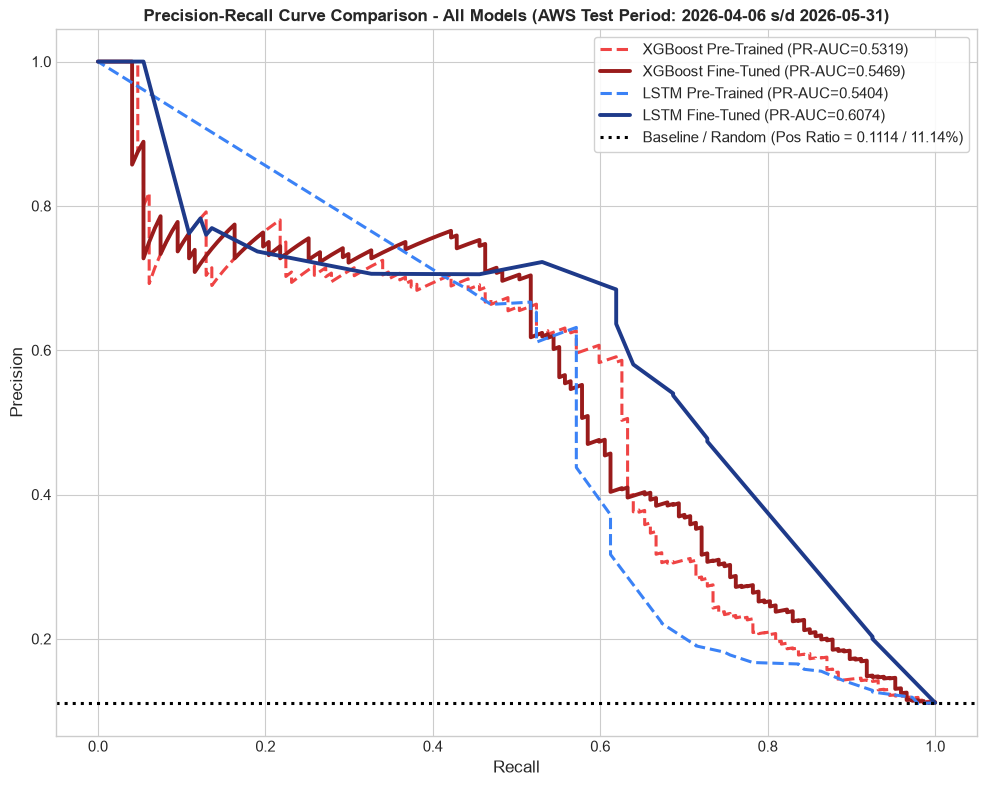

In [10]:
y_true_occ_fine = (df_test_eval['observed_aws'] >= RAIN_THRESHOLD).astype(int)
pos_ratio_fine = np.mean(y_true_occ_fine)

p_xgb_pre, r_xgb_pre, _ = precision_recall_curve(y_true_occ_fine, df_test_eval['xgb_prob_fine_pre'])
p_xgb_fine, r_xgb_fine, _ = precision_recall_curve(y_true_occ_fine, df_test_eval['xgb_prob_fine'])
p_lstm_pre, r_lstm_pre, _ = precision_recall_curve(y_true_occ_fine, df_test_eval['lstm_prob_fine_pre'])
p_lstm_fine, r_lstm_fine, _ = precision_recall_curve(y_true_occ_fine, df_test_eval['lstm_prob_fine'])

plt.figure(figsize=(10, 8))
plt.plot(r_xgb_pre, p_xgb_pre, label=f'XGBoost Pre-Trained (PR-AUC={auc(r_xgb_pre, p_xgb_pre):.4f})', color='#ef4444', linestyle='--', lw=2.2)
plt.plot(r_xgb_fine, p_xgb_fine, label=f'XGBoost Fine-Tuned (PR-AUC={auc(r_xgb_fine, p_xgb_fine):.4f})', color='#991b1b', linestyle='-', lw=2.8)
plt.plot(r_lstm_pre, p_lstm_pre, label=f'LSTM Pre-Trained (PR-AUC={auc(r_lstm_pre, p_lstm_pre):.4f})', color='#3b82f6', linestyle='--', lw=2.2)
plt.plot(r_lstm_fine, p_lstm_fine, label=f'LSTM Fine-Tuned (PR-AUC={auc(r_lstm_fine, p_lstm_fine):.4f})', color='#1e3a8a', linestyle='-', lw=2.8)

# Garis Baseline Proporsi Kelas Positif (Hujan)
plt.axhline(y=pos_ratio_fine, color='#000000', linestyle=':', lw=2.2, label=f'Baseline / Random (Pos Ratio = {pos_ratio_fine:.4f} / {pos_ratio_fine*100:.2f}%)')

plt.title(f'Precision-Recall Curve Comparison - All Models (AWS Test Period: {FINETUNE_TEST_START} s/d {FINETUNE_TEST_END})', fontsize=12, fontweight='bold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()
